In [1]:
import polars as pl
import os
import json
from pathlib import Path

NOTEBOOK_DIR = Path(os.path.abspath('')).resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parents[3]  # Fast_Data_Discovery
PAPER_ROOT = PROJECT_ROOT.parent / 'Matryoshka'

exp_path = NOTEBOOK_DIR / 'logs'
base_scores = pl.read_csv(PROJECT_ROOT / 'experiments' / 'base_tables' / 'base_simple_scores.csv').rename({'': 'table'})
aug_scores = pl.read_csv(exp_path / 'simple_results.csv').rename({'': 'experiment'})

exp_dir = os.listdir(exp_path)
runtime_res = {}
for exp in exp_dir:
    if not os.path.isdir(exp_path / exp):
        continue
    comb_log = exp_path / exp / f'{exp}.log'
    with open(comb_log) as f:
        lines = f.readlines()
    for i in range(len(lines)):
        lines[i] = json.loads(lines[i])
    df = pl.from_records(lines, orient='col')
    runtime = df.select(pl.col('runtime').sum()).to_series()[0]
    runtime_res[exp] = runtime
runtime_df = pl.from_dicts([{'experiment': k, 'runtime': v} for k, v in runtime_res.items()])
aug_scores = aug_scores.join(runtime_df, left_on='experiment', right_on='experiment', how='left')
aug_scores = aug_scores.with_columns(
    pl.col('experiment').str.split('_').list.to_struct(upper_bound=3, fields=['lake', 'table', 'model']).struct.unnest()
)
aug_scores = aug_scores.join(base_scores, on='table', how='left', suffix='_base')

aug_scores = aug_scores.with_columns((pl.col('f1_weighted_base').fill_null(0)).round(3).alias('score_base'))
aug_scores = aug_scores.with_columns((pl.col('rmse').fill_null(0) + pl.col('f1_weighted').fill_null(0)).round(3).alias('score'))
aug_scores = aug_scores.with_columns(
    pl.when(pl.col('rmse').is_not_null())
    .then(pl.lit('rmse'))
    .otherwise(pl.lit('f1'))
    .alias('metric')
)
# Create base rows for each unique (lake, table) combination
base_rows = (
    aug_scores
    .unique(subset=['lake', 'table'])
    .with_columns([
        pl.lit('base').alias('algorithm'),
        pl.col('score_base').alias('score'),
        pl.col('f1_weighted_base').alias('f1'),
        pl.lit(0.0).alias('runtime'),
        (pl.col('lake') + '_' + pl.col('table') + '_base').alias('experiment')
    ])
    .select(aug_scores.columns)
)
aug_scores = pl.concat([aug_scores, base_rows])
aug_scores = aug_scores.with_columns(
    pl.when(pl.col('table') == 'pageviews')
    .then((pl.col('score')/1e6).round(3))
    .otherwise(pl.col('score'))
    .alias('score')
)
aug_scores = aug_scores.filter(
    (pl.col('experiment').str.contains('base').not_()) &
    (pl.col('experiment').str.contains('forward'))
)

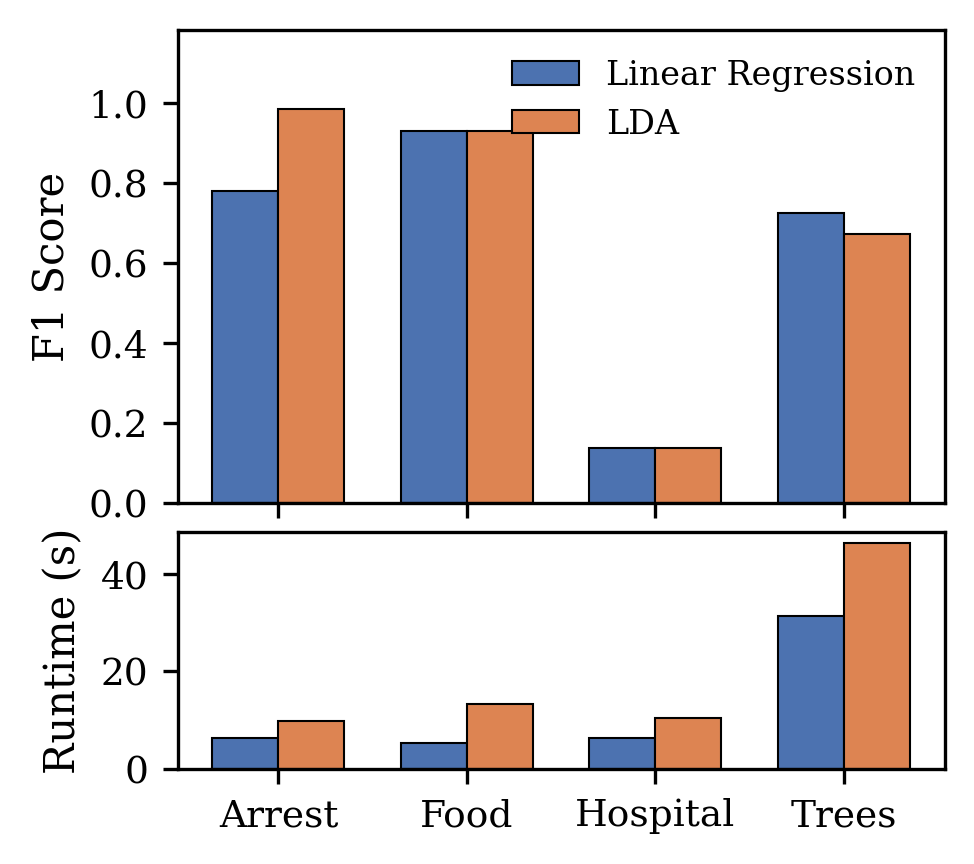

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import sys
sys.path.insert(0, str(PROJECT_ROOT / 'experiments'))
from plots_style import apply_style
apply_style()

# Prepare data
model_rename = {
    'RegressionQR': 'Linear Regression',
    'ClassificationCholesky': 'LDA',
}
dataset_order = ['arrest', 'food', 'hospital', 'trees']
dataset_display = {'arrest': 'Arrest', 'food': 'Food', 'hospital': 'Hospital', 'trees': 'Trees'}

plot_df = (
    aug_scores
    .with_columns(pl.col('model').replace(model_rename))
    .sort('table')
)

models = ['Linear Regression', 'LDA']
colors = ['#4c72b0', '#dd8452']
x = np.arange(len(dataset_order))
width = 0.35

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(3.3, 3.2), sharex=True,
                                 gridspec_kw={'height_ratios': [2, 1], 'hspace': 0.08})

for i, model in enumerate(models):
    model_data = plot_df.filter(pl.col('model') == model).sort('table')
    scores, runtimes = [], []
    for ds in dataset_order:
        row = model_data.filter(pl.col('table') == ds)
        scores.append(row['f1_weighted'][0] if len(row) > 0 else 0)
        runtimes.append(row['runtime'][0] if len(row) > 0 else 0)
    offset = (i - 0.5) * width
    ax1.bar(x + offset, scores, width, label=model,
            color=colors[i], edgecolor='black', linewidth=0.5)
    ax2.bar(x + offset, runtimes, width,
            color=colors[i], edgecolor='black', linewidth=0.5)

ax1.set_ylabel('F1 Score')
ax1.set_ylim(0, plot_df['f1_weighted'].max() * 1.2)
ax1.legend(fontsize=8)

ax2.set_ylabel('Runtime (s)')
ax2.set_xticks(x)
ax2.set_xticklabels([dataset_display[ds] for ds in dataset_order])
ax2.set_ylim(bottom=0)

fig.savefig(PAPER_ROOT / 'figures' / 'proxy_classification.pdf')
plt.show()

In [4]:
# --- Generate TikZ ---
model_rename = {
    'RegressionQR': 'Linear Regression',
    'ClassificationCholesky': 'LDA',
}
dataset_order = ['arrest', 'food', 'hospital', 'trees']
dataset_display = {'arrest': 'Arrest', 'food': 'Food', 'hospital': 'Hospital', 'trees': 'Trees'}

plot_df = aug_scores.with_columns(pl.col('model').replace(model_rename)).sort('table')

# Collect values
f1_lr, f1_lda, rt_lr, rt_lda = [], [], [], []
for ds in dataset_order:
    for model, f1_list, rt_list in [('Linear Regression', f1_lr, rt_lr), ('LDA', f1_lda, rt_lda)]:
        row = plot_df.filter((pl.col('model') == model) & (pl.col('table') == ds))
        f1_list.append(row['f1_weighted'][0] if len(row) > 0 else 0)
        rt_list.append(row['runtime'][0] if len(row) > 0 else 0)

n = len(dataset_order)
names = [dataset_display[ds] for ds in dataset_order]

tikz = [
    r"\definecolor{barblue}{RGB}{31,119,180}",
    r"\definecolor{baronge}{RGB}{255,127,14}",
    r"\begin{tikzpicture}",
    r"\begin{groupplot}[",
    r"  group style={",
    r"    group size=1 by 2,",
    r"    vertical sep=0.35cm,",
    r"    xlabels at=edge bottom,",
    r"    xticklabels at=edge bottom,",
    r"  },",
    r"  width=\linewidth,",
    f"  xtick={{{','.join(str(i) for i in range(n))}}},",
    f"  xticklabels={{{','.join(names)}}},",
    r"  x tick label style={font=\small},",
    r"  y tick label style={font=\small},",
    r"  label style={font=\small},",
    f"  xmin=-0.5,",
    f"  xmax={n - 1 + 0.5},",
    r"  enlarge x limits=false,",
    r"  axis lines=left,",
    r"  ymin=0,",
    r"]",
    r"% --- Top panel: F1 Score ---",
    r"\nextgroupplot[",
    r"  ybar,",
    r"  bar width=0.40cm,",
    r"  height=1.6in,",
    r"  ylabel={F1 Score},",
    r"  ymax=1.15,",
    r"  legend style={font=\small, at={(0.98,0.95)}, anchor=north east, draw=black, fill=white, fill opacity=0.85, text opacity=1},",
    r"]",
]

# F1 bars
coords = " ".join(f"({i},{v:.3f})" for i, v in enumerate(f1_lr))
tikz.append(r"\addplot[fill=barblue, draw=black, line width=0.5pt]")
tikz.append(f"  coordinates {{{coords}}};")
tikz.append(r"\addlegendentry{Linear Regression}")

coords = " ".join(f"({i},{v:.3f})" for i, v in enumerate(f1_lda))
tikz.append(r"\addplot[fill=baronge, draw=black, line width=0.5pt]")
tikz.append(f"  coordinates {{{coords}}};")
tikz.append(r"\addlegendentry{LDA}")

tikz += [
    r"% --- Bottom panel: Runtime ---",
    r"\nextgroupplot[",
    r"  ybar,",
    r"  bar width=0.40cm,",
    r"  height=1.1in,",
    r"  ylabel={Runtime (s)},",
    r"]",
]

# Runtime bars
coords = " ".join(f"({i},{v:.1f})" for i, v in enumerate(rt_lr))
tikz.append(r"\addplot[fill=barblue, draw=black, line width=0.5pt]")
tikz.append(f"  coordinates {{{coords}}};")

coords = " ".join(f"({i},{v:.1f})" for i, v in enumerate(rt_lda))
tikz.append(r"\addplot[fill=baronge, draw=black, line width=0.5pt]")
tikz.append(f"  coordinates {{{coords}}};")

tikz.append(r"\end{groupplot}")
tikz.append(r"\end{tikzpicture}")

tikz_code = "\n".join(tikz)
out_path = PAPER_ROOT / 'figures' / 'proxy_classification.tex'
out_path.write_text(tikz_code)
print(f"TikZ written to {out_path}")

TikZ written to /home/fedor/Matryoshka/figures/proxy_classification.tex
